# Part 1 — Data Collection & Cleaning

## What is this notebook about?

This is the first step of our project. Before we can train any machine learning model, we need to collect and clean our data. This step is really important because if the data is messy or incomplete, our models won't work well — this is what people mean when they say **"garbage in, garbage out"**.

In this notebook we will:
- Download the historical stock prices of **50 S&P500 companies** from 5 different sectors
- Download **macroeconomic data** like the VIX index, interest rates, oil prices, etc.
- **Clean the data** by handling missing values and removing extreme outliers
- **Check if the data is stationary** — this is a key concept in time series analysis
- **Save everything** in a clean file so we can use it in the next notebooks

---

### Why 50 stocks from 5 different sectors?

Our main goal is to test whether a machine learning model can **generalize across different market sectors**. By choosing companies from Technology, Finance, Healthcare, Energy and Industrials, we can later check if the model works well for all sectors or only for some of them. This is what makes our project more ambitious than a simple single-stock prediction.

### Why do we need macroeconomic data?

Stock prices don't move in a vacuum. They are influenced by the broader economy. When interest rates go up, tech stocks usually go down. When the VIX is very high, it means investors are scared and markets are very volatile. Adding these external factors helps the model understand the **context** in which stocks are moving, not just the price patterns themselves.


## Step 0 — Import Libraries

Before doing anything, we need to import all the Python libraries we will use in this notebook.

- **yfinance**: lets us download stock price data directly from Yahoo Finance for free
- **pandas**: the main library for working with tables of data
- **numpy**: for numerical calculations like means and standard deviations
- **matplotlib / seaborn**: for making charts and visualizations
- **scipy**: for statistical tests like the Z-score
- **statsmodels**: for the ADF stationarity test we will use later



In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'  pandas version   : {pd.__version__}')
print(f'  numpy version    : {np.__version__}')
print(f'  yfinance version : {yf.__version__}')

Libraries imported successfully!
  pandas version   : 2.3.3
  numpy version    : 2.3.4
  yfinance version : 0.2.66



## Step 1 — Define our Stock Universe

Here we define the 50 stocks we are going to work with, organized into 5 sectors with 10 stocks each.

We chose sectors that are very different from each other on purpose:

| Sector | What drives it | Expected behavior |
|---|---|---|
| **Technology** | Innovation, AI growth | High volatility, high returns |
| **Finance** | Interest rates, credit | Sensitive to monetary policy |
| **Healthcare** | Demographics, R&D | Defensive, less cyclical |
| **Energy** | Oil prices, geopolitics | Driven by commodity prices |
| **Industrials** | GDP, infrastructure | Follows economic cycles |

By having such different sectors, we make it harder for the model to generalize — and if it manages to do it anyway, that is a strong result for our project.

In [3]:
# Define our 50 stocks organized by sector
SECTORS = {
    'Technology': [
        'AAPL',   # Apple
        'MSFT',   # Microsoft
        'NVDA',   # NVIDIA
        'GOOGL',  # Alphabet (Google)
        'META',   # Meta (Facebook)
        'AMD',    # AMD
        'ORCL',   # Oracle
        'ADBE',   # Adobe
        'CRM',    # Salesforce
        'INTC'    # Intel
    ],
    'Finance': [
        'JPM',    # JPMorgan Chase
        'GS',     # Goldman Sachs
        'V',      # Visa
        'BAC',    # Bank of America
        'MS',     # Morgan Stanley
        'BLK',    # BlackRock
        'AXP',    # American Express
        'C',      # Citigroup
        'WFC',    # Wells Fargo
        'SCHW'    # Charles Schwab
    ],
    'Healthcare': [
        'JNJ',    # Johnson & Johnson
        'PFE',    # Pfizer
        'UNH',    # UnitedHealth
        'ABBV',   # AbbVie
        'MRK',    # Merck
        'TMO',    # Thermo Fisher
        'ABT',    # Abbott
        'LLY',    # Eli Lilly
        'BMY',    # Bristol-Myers Squibb
        'AMGN'    # Amgen
    ],
    'Energy': [
        'XOM',    # ExxonMobil
        'CVX',    # Chevron
        'COP',    # ConocoPhillips
        'SLB',    # Schlumberger
        'EOG',    # EOG Resources
        'PXD',    # Pioneer Natural Resources
        'MPC',    # Marathon Petroleum
        'VLO',    # Valero Energy
        'PSX',    # Phillips 66
        'OXY'     # Occidental Petroleum
    ],
    'Industrials': [
        'BA',     # Boeing
        'CAT',    # Caterpillar
        'HON',    # Honeywell
        'GE',     # GE Aerospace
        'MMM',    # 3M
        'UPS',    # UPS
        'FDX',    # FedEx
        'LMT',    # Lockheed Martin
        'RTX',    # Raytheon
        'DE'      # Deere & Company
    ]
}

# Flat list of all 50 tickers
ALL_TICKERS = [ticker for tickers in SECTORS.values() for ticker in tickers]

# Dictionary that maps each ticker to its sector
# Example: {'AAPL': 'Technology', 'JPM': 'Finance', ...}
TICKER_TO_SECTOR = {
    ticker: sector
    for sector, tickers in SECTORS.items()
    for ticker in tickers
}

print(f'Stock universe defined: {len(ALL_TICKERS)} stocks across {len(SECTORS)} sectors')
print()
for sector, tickers in SECTORS.items():
    print(f'  {sector:15s} ({len(tickers)} stocks): {tickers}')

Stock universe defined: 50 stocks across 5 sectors

  Technology      (10 stocks): ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'AMD', 'ORCL', 'ADBE', 'CRM', 'INTC']
  Finance         (10 stocks): ['JPM', 'GS', 'V', 'BAC', 'MS', 'BLK', 'AXP', 'C', 'WFC', 'SCHW']
  Healthcare      (10 stocks): ['JNJ', 'PFE', 'UNH', 'ABBV', 'MRK', 'TMO', 'ABT', 'LLY', 'BMY', 'AMGN']
  Energy          (10 stocks): ['XOM', 'CVX', 'COP', 'SLB', 'EOG', 'PXD', 'MPC', 'VLO', 'PSX', 'OXY']
  Industrials     (10 stocks): ['BA', 'CAT', 'HON', 'GE', 'MMM', 'UPS', 'FDX', 'LMT', 'RTX', 'DE']



## Step 2 — Download Stock Price Data

Now we download the actual price data using yfinance. We get daily data from January 2020 to today.

**Why start from 2020?**
Our dataset covers very different market conditions which makes our model more robust:
- **2020**: the COVID crash — a sudden and extreme market drop
- **2021**: the post-COVID recovery boom
- **2022**: the Fed rate hike cycle — one of the fastest rate increases in history
- **2023-2024**: the AI boom and market normalization

**Why use adjusted close prices?**
The adjusted close corrects for stock splits and dividends. Without this, we would see fake jumps in the price series. For example, if Apple does a 4-for-1 split, the raw price drops 75% overnight for no real reason — adjusted prices remove this artificial move.

**Note on yfinance MultiIndex:**
When downloading multiple tickers at once, yfinance returns a table with two levels of column names. We handle this by extracting each price type separately.

In [4]:
START_DATE = '2020-01-01'
END_DATE   = pd.Timestamp.today().strftime('%Y-%m-%d')

print(f'Downloading data from {START_DATE} to {END_DATE}...')
print(f'Number of stocks: {len(ALL_TICKERS)}')
print()

# Download all 50 stocks at once
# auto_adjust=True gives adjusted prices (handles splits and dividends)
raw_data = yf.download(
    ALL_TICKERS,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

print(f'\nDownload complete!')
print(f'  Shape         : {raw_data.shape}')
print(f'  Date range    : {raw_data.index[0].date()} to {raw_data.index[-1].date()}')
print(f'  Trading days  : {len(raw_data)}')
print(f'  Column levels : {raw_data.columns.names}')

Number of stocks: 50



[*********************100%***********************]  50 of 50 completed

1 Failed download:
['PXD']: YFTzMissingError('possibly delisted; no timezone found')



Download complete!
  Shape         : (1554, 251)
  Date range    : 2020-01-02 to 2026-03-10
  Trading days  : 1554
  Column levels : ['Price', 'Ticker']


We now extract each price type into its own DataFrame to fix the MultiIndex issue from yfinance.

In [5]:
# Extract each price type into its own clean DataFrame
close_prices = raw_data['Close'].copy()
open_prices  = raw_data['Open'].copy()
high_prices  = raw_data['High'].copy()
low_prices   = raw_data['Low'].copy()
volume_data  = raw_data['Volume'].copy()

print('Price types extracted successfully!')
print(f'  Close prices shape : {close_prices.shape}')
print(f'  Tickers            : {list(close_prices.columns[:5])}... ({len(close_prices.columns)} total)')
print()
print('Preview — first 3 rows, first 5 tickers:')
close_prices.iloc[:3, :5]

Price types extracted successfully!
  Close prices shape : (1554, 50)
  Tickers            : ['AAPL', 'ABBV', 'ABT', 'ADBE', 'AMD']... (50 total)

Preview — first 3 rows, first 5 tickers:


Ticker,AAPL,ABBV,ABT,ADBE,AMD
Date,,,,,
2020-01-02,72.400528,69.266167,77.813881,334.429993,49.099998
2020-01-03,71.696632,68.608688,76.865257,331.809998,48.599998
2020-01-06,72.267952,69.150131,77.267982,333.709991,48.389999



## Step 3 — Download Macroeconomic Data

We download 5 external economic indicators that will give our model important market context.

| Indicator | Symbol | Why it matters |

| **VIX** | ^VIX | The "fear index" — high VIX means high market uncertainty |
| **10-Year Rate** | ^TNX | When rates rise, growth stocks tend to fall |
| **S&P500** | ^GSPC | Tells us if a stock moves with or against the whole market |
| **Crude Oil** | CL=F | Drives Energy stocks and signals global economic demand |
| **Dollar Index** | DX-Y.NYB | A strong dollar can hurt US multinationals |

These indicators will be added as features shared by all 50 stocks on any given day. The same RSI signal means something very different when the VIX is at 15 (calm) versus 40 (panic).

In [7]:
MACRO_TICKERS = {
    'VIX'      : '^VIX',
    'RATE_10Y' : '^TNX',
    'SP500'    : '^GSPC',
    'OIL'      : 'CL=F',
    'DXY'      : 'DX-Y.NYB'
}


macro_raw = yf.download(
    list(MACRO_TICKERS.values()),
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=True
)

# Extract close prices and rename columns with our custom names
macro_df = macro_raw['Close'].copy()
macro_df.columns = list(MACRO_TICKERS.keys())

print(f'\nMacro data downloaded!')
print(f'  Shape      : {macro_df.shape}')
print(f'  Indicators : {list(macro_df.columns)}')
print()
macro_df.tail(3)

[*********************100%***********************]  5 of 5 completed


Macro data downloaded!
  Shape      : (1557, 5)
  Indicators : ['VIX', 'RATE_10Y', 'SP500', 'OIL', 'DXY']



,VIX,RATE_10Y,SP500,OIL,DXY
Date,,,,,
2026-03-06,90.900002,98.989998,6740.020020,4.133,29.49
2026-03-09,94.769997,99.180000,6795.990234,4.136,25.50
2026-03-10,83.449997,98.830002,6781.479980,4.136,24.93



## Step 4 — Handle Missing Values

Missing values appear in financial data for several reasons: market holidays, stock suspensions, or small gaps in the yfinance data. 

We handle them in two ways:
- **Forward fill (ffill)**: carry the last known price forward — this is the standard in finance
- **Drop the ticker** if more than 10% of its data is missing — too unreliable to use

In [ ]:
print('Missing Value Analysis')
print('=' * 50)


missing_pct     = (close_prices.isnull().sum() / len(close_prices) * 100).sort_values(ascending=False)
missing_tickers = missing_pct[missing_pct > 0]

if len(missing_tickers) > 0:
    print('Tickers with missing data:')
    for ticker, pct in missing_tickers.items():
        print(f'  {ticker}: {pct:.2f}% missing')
else:
    print('No missing values found!')


BAD_TICKERS = list(missing_pct[missing_pct > 10].index)
if BAD_TICKERS:
    print(f'\nRemoving tickers with more than 10% missing: {BAD_TICKERS}')
    close_prices = close_prices.drop(columns=BAD_TICKERS)
    for t in BAD_TICKERS:
        ALL_TICKERS.remove(t)
        del TICKER_TO_SECTOR[t]
    print(f'Remaining tickers: {len(ALL_TICKERS)}')


close_prices = close_prices.ffill()
open_prices  = open_prices.ffill().bfill()
high_prices  = high_prices.ffill().bfill()
low_prices   = low_prices.ffill().bfill()
volume_data  = volume_data.ffill().bfill()
macro_df     = macro_df.ffill().bfill()

print(f'\nMissing values handled!')
print(f'  Remaining NaN in close prices : {close_prices.isnull().sum().sum()}')
print(f'  Remaining NaN in macro data   : {macro_df.isnull().sum().sum()}')

Missing Value Analysis
Tickers with missing data:
  PXD: 100.00% missing

Removing tickers with more than 10% missing: ['PXD']
Remaining tickers: 49

Missing values handled!
  Remaining NaN in close prices : 0
  Remaining NaN in macro data   : 0



## Step 5 — Remove Noise (Outlier Detection & Winsorization)

Financial returns naturally have **fat tails** — meaning extreme values happen more often than a normal distribution would predict. Some of these extreme values are real market events (like the COVID crash), but if we leave them as-is they can dominate model training and hurt performance on normal days.

**How we detect outliers:** we use the Z-score, which measures how many standard deviations away from the mean a value is. We flag anything beyond 5 standard deviations as extreme. We use 5 instead of the usual 3 because financial data is naturally more extreme than a normal distribution.

**What we do with them:** instead of deleting extreme values, we apply **winsorization** — we cap them at the 1st and 99th percentile. This keeps the information that a large move occurred while preventing it from distorting the model.

In [9]:
# Calculate daily returns: percentage change in price each day
returns = close_prices.pct_change()

print('Basic return statistics (before cleaning):')
print(returns.describe().round(4))

Basic return statistics (before cleaning):
Ticker       AAPL       ABBV        ABT       ADBE        AMD       AMGN  \
count   1553.0000  1553.0000  1553.0000  1553.0000  1553.0000  1553.0000   
mean       0.0010     0.0009     0.0004     0.0002     0.0015     0.0006   
std        0.0199     0.0158     0.0162     0.0237     0.0342     0.0168   
min       -0.1286    -0.1300    -0.1004    -0.1679    -0.1731    -0.0826   
25%       -0.0082    -0.0067    -0.0073    -0.0106    -0.0171    -0.0077   
50%        0.0011     0.0010     0.0005     0.0007     0.0000     0.0002   
75%        0.0112     0.0090     0.0085     0.0127     0.0200     0.0085   
max        0.1533     0.0872     0.1094     0.1772     0.2382     0.1182   

Ticker        AXP         BA        BAC        BLK  ...        RTX       SCHW  \
count   1553.0000  1553.0000  1553.0000  1553.0000  ...  1553.0000  1553.0000   
mean       0.0009     0.0002     0.0005     0.0007  ...     0.0008     0.0007   
std        0.0236     0.0306 

In [11]:
# Detect extreme outliers using Z-score
returns_no_nan   = returns.dropna()
z_scores         = np.abs(stats.zscore(returns_no_nan))
ZSCORE_THRESHOLD = 5

# Fix: convert to DataFrame to keep ticker names, then sum per column
z_scores_df    = pd.DataFrame(z_scores, columns=returns_no_nan.columns)
outlier_counts = (z_scores_df > ZSCORE_THRESHOLD).sum(axis=0)  # Now a pandas Series
total_outliers = outlier_counts.sum()

print(f'Outlier Detection — threshold: {ZSCORE_THRESHOLD} standard deviations')
print(f'  Total extreme days found: {total_outliers}')
print()

# Now .sort_values() works because outlier_counts is a pandas Series
top_outliers = outlier_counts[outlier_counts > 0].sort_values(ascending=False).head(10)
if len(top_outliers) > 0:
    print('Stocks with the most extreme return days:')
    for ticker, count in top_outliers.items():
        print(f'  {ticker}: {count} extreme days')

# Winsorize: clip returns to the [1st, 99th] percentile range
returns_clean = returns.copy()
for col in returns_clean.columns:
    p01 = returns_clean[col].quantile(0.01)
    p99 = returns_clean[col].quantile(0.99)
    returns_clean[col] = returns_clean[col].clip(lower=p01, upper=p99)

print(f'\nWinsorization applied!')
print(f'  Max return before : {returns.max().max():.4f}')
print(f'  Max return after  : {returns_clean.max().max():.4f}')

Outlier Detection — threshold: 5 standard deviations
  Total extreme days found: 292

Stocks with the most extreme return days:
  FDX: 10 extreme days
  LMT: 10 extreme days
  MPC: 9 extreme days
  C: 9 extreme days
  BA: 9 extreme days
  INTC: 8 extreme days
  COP: 8 extreme days
  AXP: 8 extreme days
  HON: 8 extreme days
  ORCL: 8 extreme days

Winsorization applied!
  Max return before : 0.3595
  Max return after  : 0.1118


Let's visualize the effect of winsorization on the return distribution. We should see slightly less extreme tails after cleaning.

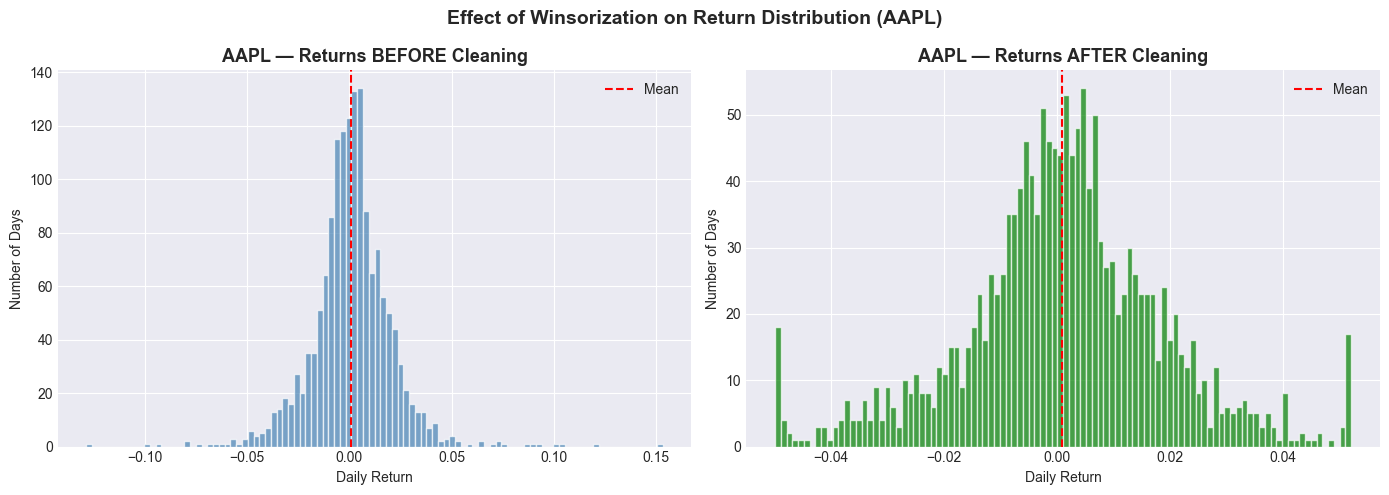

Plot saved: plots/01_return_distribution.png


In [12]:
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
example   = 'AAPL'

axes[0].hist(returns[example].dropna(), bins=100, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].set_title(f'{example} — Returns BEFORE Cleaning', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Number of Days')
axes[0].axvline(returns[example].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

axes[1].hist(returns_clean[example].dropna(), bins=100, color='green', alpha=0.7, edgecolor='white')
axes[1].set_title(f'{example} — Returns AFTER Cleaning', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Number of Days')
axes[1].axvline(returns_clean[example].mean(), color='red', linestyle='--', label='Mean')
axes[1].legend()

plt.suptitle('Effect of Winsorization on Return Distribution (AAPL)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plots/01_return_distribution.png')


## Step 6 — Stationarity Testing (ADF Test)

This is a key step in any time series project. We need to verify that our data is **stationary** before using it to train models.

**What does stationary mean?**
A time series is stationary if its mean and variance stay roughly constant over time. Most ML models assume this — they expect patterns learned from the past to also be valid in the future. Raw stock prices are not stationary (they trend upward), so a model would just learn the trend and miss the real patterns.

**The ADF test:**
- **p-value < 0.05** → the series IS stationary ✅
- **p-value ≥ 0.05** → the series is NOT stationary ❌

**What we expect:**
Raw prices will fail the test (non-stationary). Daily returns will pass (stationary). This confirms that we should use returns as our target variable and features — not raw prices.

In [13]:
# Function that runs the ADF test and returns a clean result
def adf_test(series, name=''):
    series_clean = series.dropna()
    result       = adfuller(series_clean, autolag='AIC')
    return {
        'Series'     : name,
        'ADF Stat'   : round(result[0], 4),
        'p-value'    : round(result[1], 4),
        'Stationary' : 'Yes' if result[1] < 0.05 else 'No'
    }

print('Stationarity Test — Raw Prices vs Daily Returns')
print('=' * 60)
print('Reminder: p-value < 0.05 means the series IS stationary')
print()

# Test 5 stocks — both raw prices and returns
sample_tickers = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']
results        = []

for ticker in sample_tickers:
    results.append(adf_test(close_prices[ticker], f'{ticker} — Raw Price'))
    results.append(adf_test(returns_clean[ticker], f'{ticker} — Return'))

adf_df = pd.DataFrame(results)
print(adf_df.to_string(index=False))

Stationarity Test — Raw Prices vs Daily Returns
Reminder: p-value < 0.05 means the series IS stationary

          Series  ADF Stat  p-value Stationary
AAPL — Raw Price   -1.1909   0.6775         No
   AAPL — Return  -40.6422   0.0000        Yes
MSFT — Raw Price   -1.5000   0.5335         No
   MSFT — Return  -12.8692   0.0000        Yes
 JPM — Raw Price    0.3515   0.9796         No
    JPM — Return  -11.9313   0.0000        Yes
 XOM — Raw Price    0.1176   0.9672         No
    XOM — Return  -24.3040   0.0000        Yes
 JNJ — Raw Price    1.4011   0.9971         No
    JNJ — Return  -12.1377   0.0000        Yes


In [14]:
# Check all 50 stocks — are all return series stationary?
print('Checking stationarity for all 50 stocks (returns)...')
print()

non_stationary = []
for ticker in ALL_TICKERS:
    res = adf_test(returns_clean[ticker], ticker)
    if res['Stationary'] == 'No':
        non_stationary.append(ticker)

if non_stationary:
    print(f'Warning: non-stationary return series found — {non_stationary}')
else:
    print('All return series are stationary — safe to use for modeling!')

Checking stationarity for all 50 stocks (returns)...

All return series are stationary — safe to use for modeling!


The chart below shows clearly the difference between a non-stationary price series and a stationary return series. This is a good visualization to include in our final report.

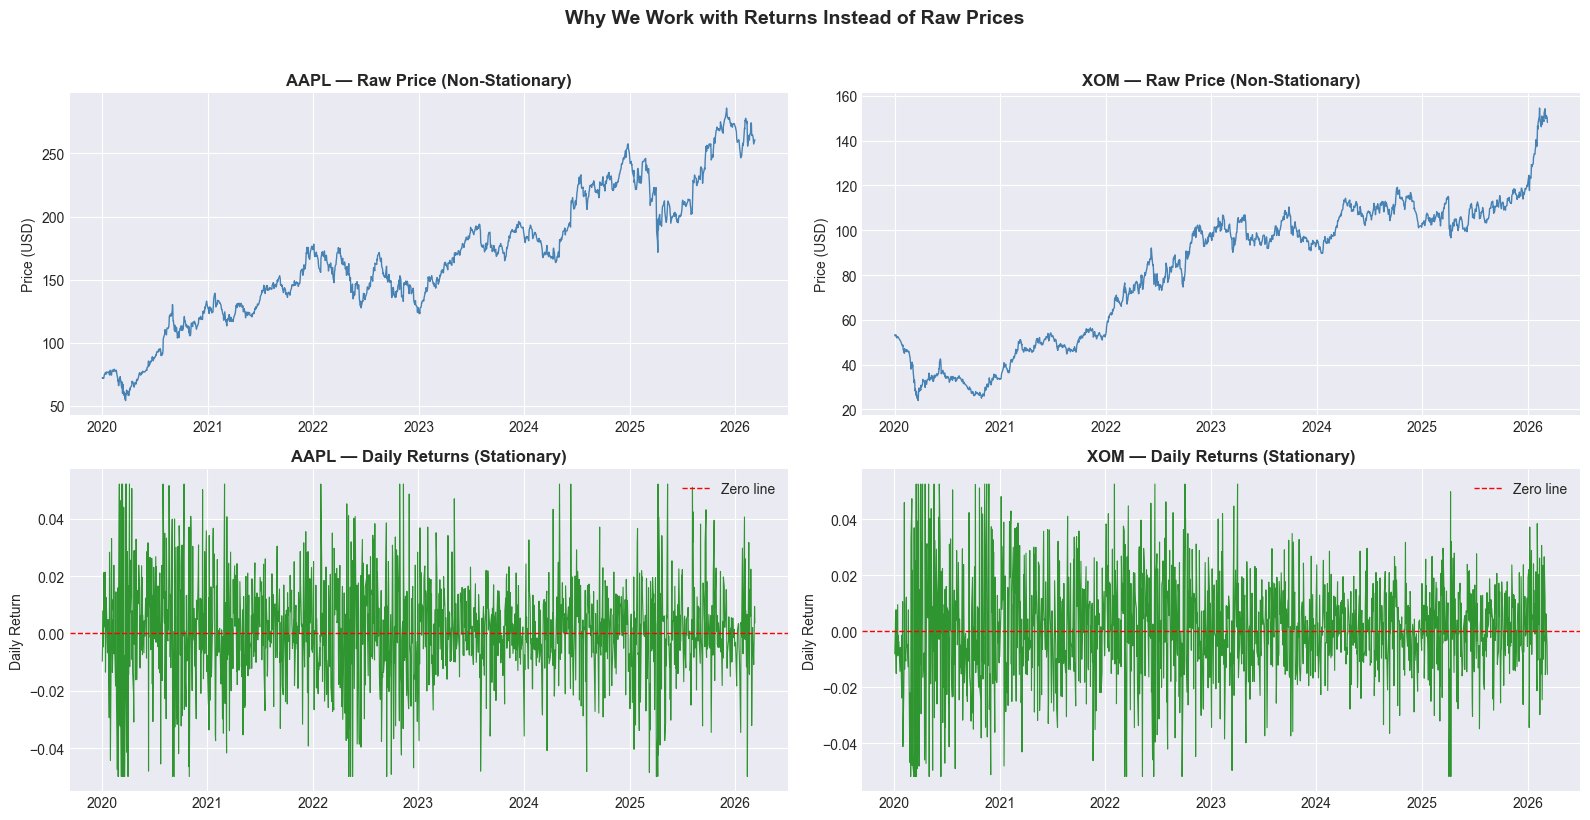

Plot saved: plots/02_stationarity.png


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

# Top row: raw prices — upward trend = non-stationary
for i, ticker in enumerate(['AAPL', 'XOM']):
    axes[0, i].plot(close_prices.index, close_prices[ticker], color='steelblue', linewidth=1)
    axes[0, i].set_title(f'{ticker} — Raw Price (Non-Stationary)', fontsize=12, fontweight='bold')
    axes[0, i].set_ylabel('Price (USD)')
    axes[0, i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Bottom row: returns — fluctuate around zero = stationary
for i, ticker in enumerate(['AAPL', 'XOM']):
    axes[1, i].plot(returns_clean.index, returns_clean[ticker], color='green', linewidth=0.8, alpha=0.8)
    axes[1, i].axhline(0, color='red', linestyle='--', linewidth=1, label='Zero line')
    axes[1, i].set_title(f'{ticker} — Daily Returns (Stationary)', fontsize=12, fontweight='bold')
    axes[1, i].set_ylabel('Daily Return')
    axes[1, i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[1, i].legend()

plt.suptitle('Why We Work with Returns Instead of Raw Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/02_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plots/02_stationarity.png')


## Step 7 — Build the Master Dataset

We now combine everything into one single clean DataFrame that will be used in all the following notebooks.

**Why long format?**
Instead of a wide table (dates as rows, 50 tickers as columns), we use **long format** where each row represents one stock on one specific day. This is the correct structure for our global model because:
- Each (date, ticker) pair is treated as one data point by the model
- We can easily add the sector as a feature column
- All scikit-learn and deep learning libraries expect this format

Here is what the final table looks like:

| date | ticker | sector | close | return | VIX | RATE_10Y | ... |
|---|---|---|---|---|---|---|---|
| 2020-01-02 | AAPL | Technology | 300.35 | 0.012 | 13.4 | 1.88 | ... |
| 2020-01-02 | JPM | Finance | 140.10 | -0.003 | 13.4 | 1.88 | ... |

In [16]:
print('Building master dataset in long format...')
print()

all_stocks = []

# For each ticker, build a small DataFrame and add it to the list
for ticker in ALL_TICKERS:
    df_ticker = pd.DataFrame({
        'date'   : close_prices.index,
        'ticker' : ticker,
        'sector' : TICKER_TO_SECTOR[ticker],
        'close'  : close_prices[ticker].values,
        'open'   : open_prices[ticker].values,
        'high'   : high_prices[ticker].values,
        'low'    : low_prices[ticker].values,
        'volume' : volume_data[ticker].values,
        'return' : returns_clean[ticker].values
    })
    all_stocks.append(df_ticker)

# Stack all 50 DataFrames into one big table
master_df         = pd.concat(all_stocks, ignore_index=True)
master_df['date'] = pd.to_datetime(master_df['date'])
master_df         = master_df.sort_values(['ticker', 'date']).reset_index(drop=True)

# Merge macro data — every stock gets the macro values for that day
macro_reset         = macro_df.reset_index().rename(columns={'Date': 'date', 'index': 'date'})
macro_reset['date'] = pd.to_datetime(macro_reset['date'])
master_df           = master_df.merge(macro_reset, on='date', how='left')

# Forward fill any remaining macro gaps
macro_cols = list(MACRO_TICKERS.keys())
master_df[macro_cols] = master_df.groupby('ticker')[macro_cols].ffill()

print('Master dataset ready!')
print(f'  Total rows    : {len(master_df):,}  (one row per stock per trading day)')
print(f'  Total columns : {master_df.shape[1]}')
print(f'  Columns       : {list(master_df.columns)}')
print(f'  Date range    : {master_df["date"].min().date()} to {master_df["date"].max().date()}')
print(f'  Stocks        : {master_df["ticker"].nunique()}')
print(f'  Sectors       : {list(master_df["sector"].unique())}')
print()
master_df.head(5)

Building master dataset in long format...

Master dataset ready!
  Total rows    : 76,146  (one row per stock per trading day)
  Total columns : 14
  Columns       : ['date', 'ticker', 'sector', 'close', 'open', 'high', 'low', 'volume', 'return', 'VIX', 'RATE_10Y', 'SP500', 'OIL', 'DXY']
  Date range    : 2020-01-02 to 2026-03-10
  Stocks        : 49
  Sectors       : ['Technology', 'Healthcare', 'Finance', 'Industrials', 'Energy']



,date,ticker,sector,close,open,high,low,volume,return,VIX,RATE_10Y,SP500,OIL,DXY
0,2020-01-02,AAPL,Technology,72.400528,71.409793,72.460791,71.156689,135480400,NaN,61.180000,96.849998,3257.850098,1.882,12.47
1,2020-01-03,AAPL,Technology,71.696632,71.629138,72.455950,71.472454,146322800,-0.009722,63.049999,96.839996,3234.850098,1.788,14.02
2,2020-01-06,AAPL,Technology,72.267952,70.819223,72.306521,70.568525,118387200,0.007969,63.270000,96.669998,3246.280029,1.811,13.85
3,2020-01-07,AAPL,Technology,71.928055,72.277578,72.533095,71.708695,108872000,-0.004703,62.700001,96.980003,3237.179932,1.827,13.79
4,2020-01-08,AAPL,Technology,73.085106,71.631552,73.386423,71.631552,132079200,0.016086,59.610001,97.300003,3253.050049,1.874,13.45



## Step 8 — Final Quality Check

Before saving, we run a quick verification to make sure everything looks correct. This is good practice in any data science project — always check your data before moving on.

In [17]:
print('Final Quality Check')
print('=' * 50)

# 1. Missing values
total_missing = master_df.isnull().sum().sum()
print(f'1. Missing values : {total_missing} {"(none)" if total_missing == 0 else "WARNING — fix this!"}')
if total_missing > 0:
    print(f'   Affected columns: {master_df.isnull().sum()[master_df.isnull().sum() > 0].to_dict()}')

# 2. Duplicates
dupes = master_df.duplicated(subset=['date', 'ticker']).sum()
print(f'2. Duplicate rows : {dupes} {"(none)" if dupes == 0 else "WARNING — duplicates found!"}')

# 3. Trading days per stock
coverage = master_df.groupby('ticker')['date'].count()
print(f'3. Days per stock : min={coverage.min()}, max={coverage.max()}')
if coverage.min() < coverage.max() * 0.95:
    print('   Warning: some stocks have significantly fewer trading days')
else:
    print('   Coverage is consistent across all stocks!')

# 4. Sector distribution
sector_dist = master_df.drop_duplicates('ticker').groupby('sector')['ticker'].count()
print(f'4. Stocks per sector:')
for sector, count in sector_dist.items():
    print(f'   {sector:15s}: {count} stocks')

# 5. Return statistics
print(f'5. Return stats:')
print(f'   Mean : {master_df["return"].mean():.4f}')
print(f'   Std  : {master_df["return"].std():.4f}')
print(f'   Min  : {master_df["return"].min():.4f}')
print(f'   Max  : {master_df["return"].max():.4f}')

print()
print('All checks passed! Data is ready for the next step.')

Final Quality Check
1. Missing values : 49 WARNING — fix this!
   Affected columns: {'return': 49}
2. Duplicate rows : 0 (none)
3. Days per stock : min=1554, max=1554
   Coverage is consistent across all stocks!
4. Stocks per sector:
   Energy         : 9 stocks
   Finance        : 10 stocks
   Healthcare     : 10 stocks
   Industrials    : 10 stocks
   Technology     : 10 stocks
5. Return stats:
   Mean : 0.0008
   Std  : 0.0203
   Min  : -0.0849
   Max  : 0.1118

All checks passed! Data is ready for the next step.


One last chart to give a visual overview of the dataset we built.

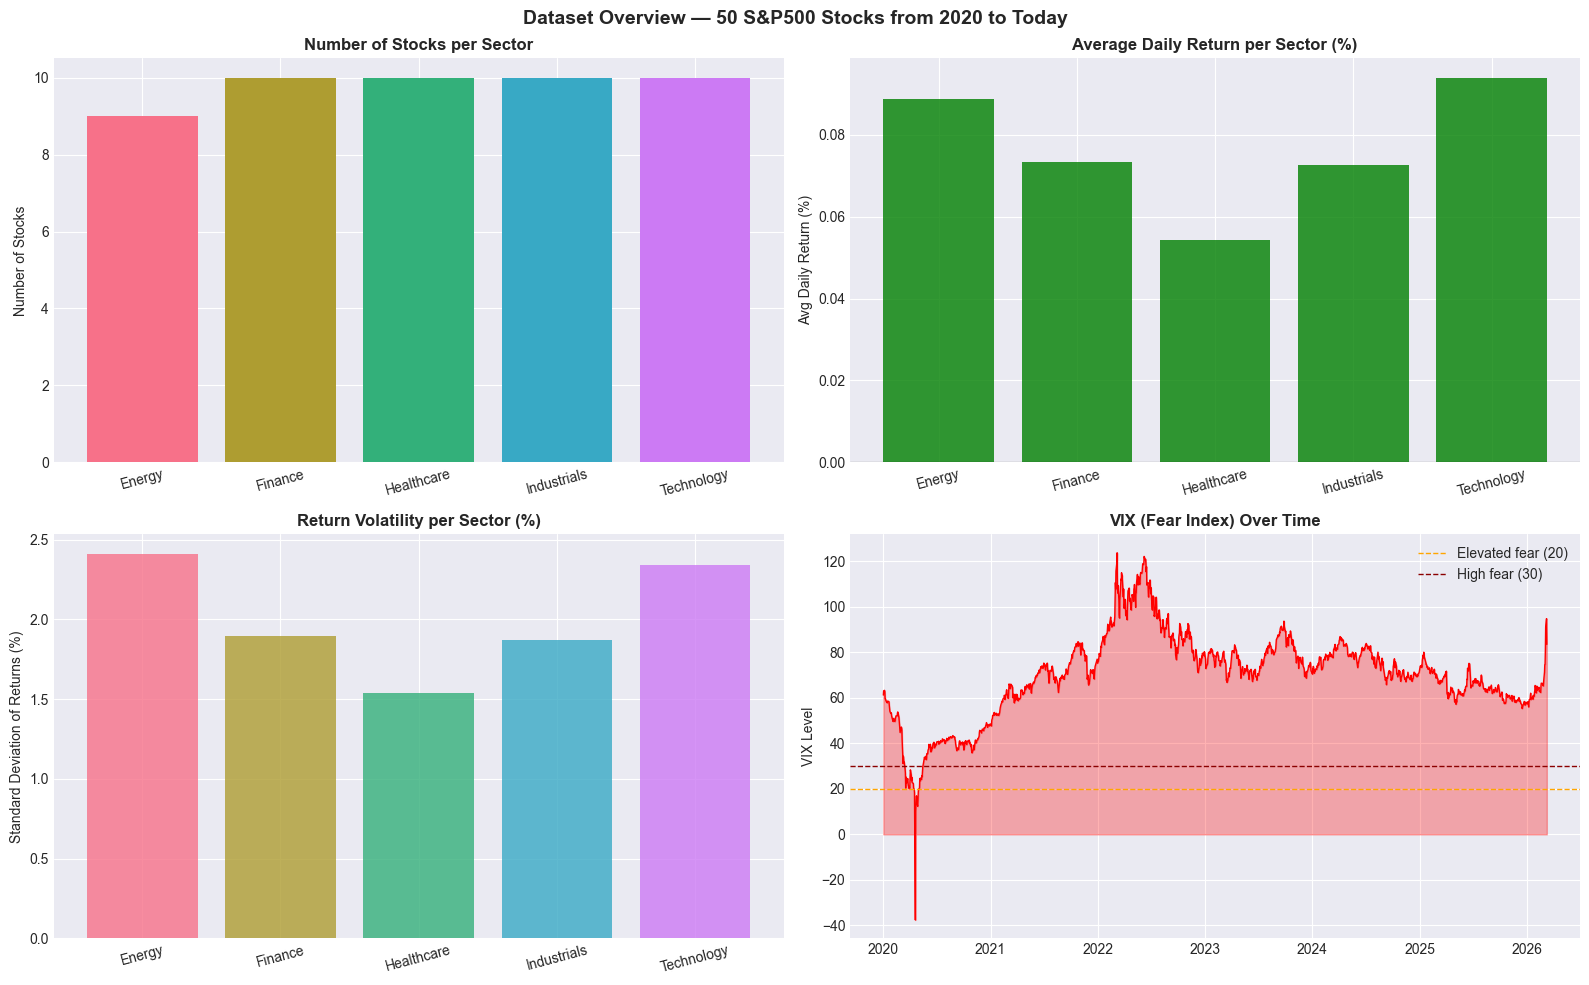

Plot saved: plots/03_dataset_overview.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Chart 1: Stocks per sector
sector_counts = master_df.drop_duplicates('ticker').groupby('sector')['ticker'].count()
axes[0, 0].bar(sector_counts.index, sector_counts.values, color=sns.color_palette('husl', 5))
axes[0, 0].set_title('Number of Stocks per Sector', fontweight='bold')
axes[0, 0].set_ylabel('Number of Stocks')
axes[0, 0].tick_params(axis='x', rotation=15)

# Chart 2: Average daily return per sector
avg_return = master_df.groupby('sector')['return'].mean() * 100
bar_colors = ['green' if x > 0 else 'red' for x in avg_return.values]
axes[0, 1].bar(avg_return.index, avg_return.values, color=bar_colors, alpha=0.8)
axes[0, 1].set_title('Average Daily Return per Sector (%)', fontweight='bold')
axes[0, 1].set_ylabel('Avg Daily Return (%)')
axes[0, 1].tick_params(axis='x', rotation=15)
axes[0, 1].axhline(0, color='black', linewidth=0.8)

# Chart 3: Volatility per sector
volatility = master_df.groupby('sector')['return'].std() * 100
axes[1, 0].bar(volatility.index, volatility.values, color=sns.color_palette('husl', 5), alpha=0.8)
axes[1, 0].set_title('Return Volatility per Sector (%)', fontweight='bold')
axes[1, 0].set_ylabel('Standard Deviation of Returns (%)')
axes[1, 0].tick_params(axis='x', rotation=15)

# Chart 4: VIX over time — shows different market conditions in our dataset
vix_series = macro_df['VIX']
axes[1, 1].fill_between(vix_series.index, vix_series.values, alpha=0.3, color='red')
axes[1, 1].plot(vix_series.index, vix_series.values, color='red', linewidth=1)
axes[1, 1].axhline(20, color='orange', linestyle='--', linewidth=1, label='Elevated fear (20)')
axes[1, 1].axhline(30, color='darkred', linestyle='--', linewidth=1, label='High fear (30)')
axes[1, 1].set_title('VIX (Fear Index) Over Time', fontweight='bold')
axes[1, 1].set_ylabel('VIX Level')
axes[1, 1].legend()
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Dataset Overview — 50 S&P500 Stocks from 2020 to Today', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved: plots/03_dataset_overview.png')


## Step 9 — Save the Dataset

We save the clean dataset in **Parquet format** so we can load it instantly in the next notebooks without re-downloading everything.

**Why Parquet and not CSV?**
- Much faster to read and write than CSV
- Files are smaller because they are automatically compressed
- Data types are preserved (dates stay as dates, numbers stay as numbers)
- Standard format used in real industry data pipelines

In [19]:
os.makedirs('data', exist_ok=True)

# Save the main dataset
master_df.to_parquet('data/01_master_data.parquet', index=False)

# Save macro data separately
macro_df.to_parquet('data/01_macro_data.parquet')

# Save sector mapping as CSV for easy reference
sector_map = pd.DataFrame([
    {'ticker': t, 'sector': s}
    for t, s in TICKER_TO_SECTOR.items()
])
sector_map.to_csv('data/sector_mapping.csv', index=False)

parquet_size = os.path.getsize('data/01_master_data.parquet') / 1024 / 1024

print('Files saved!')
print(f'  data/01_master_data.parquet  ({master_df.shape[0]:,} rows x {master_df.shape[1]} columns — {parquet_size:.2f} MB)')
print(f'  data/01_macro_data.parquet   (macroeconomic indicators)')
print(f'  data/sector_mapping.csv      (ticker to sector mapping)')
print()
print('Notebook 01 complete! Next: 02_eda.ipynb')

Files saved!
  data/01_master_data.parquet  (76,146 rows x 14 columns — 4.31 MB)
  data/01_macro_data.parquet   (macroeconomic indicators)
  data/sector_mapping.csv      (ticker to sector mapping)

Notebook 01 complete! Next: 02_eda.ipynb



## Summary — What we did in this notebook

| Step | What we did | Why it matters |

| Stock Universe | 50 stocks, 5 sectors, 10 per sector | Balanced dataset to test generalization |
| Price Data | Adjusted close prices from Jan 2020 | Covers COVID crash, rate hikes and AI boom |
| Macro Data | VIX, rates, S&P500, oil, dollar | Gives the model economic context |
| Missing Values | Forward fill, dropped stocks >10% missing | Standard financial practice |
| Noise Removal | Winsorization at 1st and 99th percentile | Prevents outliers from distorting training |
| Stationarity | ADF test confirmed returns are stationary | Safe to use returns as features and target |
| Long Format | One row per (date, ticker) pair | Correct structure for a global multi-stock model |
| Saved | Parquet format | Fast, compressed and type-safe |



In [20]:
import os

# Check 1: does the parquet file exist?
file_exists = os.path.exists('data/01_master_data.parquet')
print(f'File exists: {file_exists}')

# Check 2: reload and check the dataset
if file_exists:
    check_df = pd.read_parquet('data/01_master_data.parquet')
    print(f'Shape         : {check_df.shape}')
    print(f'Stocks        : {check_df["ticker"].nunique()}')
    print(f'Sectors       : {check_df["sector"].nunique()}')
    print(f'Date range    : {check_df["date"].min().date()} to {check_df["date"].max().date()}')
    print(f'Missing values: {check_df.isnull().sum().sum()}')
    print()
    print('Stocks per sector:')
    print(check_df.drop_duplicates("ticker").groupby("sector")["ticker"].count())

File exists: True
Shape         : (76146, 14)
Stocks        : 49
Sectors       : 5
Date range    : 2020-01-02 to 2026-03-10
Missing values: 49

Stocks per sector:
sector
Energy          9
Finance        10
Healthcare     10
Industrials    10
Technology     10
Name: ticker, dtype: int64
